<a href="https://colab.research.google.com/github/Aryan-yadav7/ML_learning/blob/main/Loan_approval_naive_bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
df = pd.read_csv("07_loan_approval.csv")

In [4]:
X = df.drop("LoanApproved", axis=1)
y = df["LoanApproved"]

In [5]:
X = X.drop("ApplicantID", axis=1)

In [6]:
categorical_cols = [
    "Education",
    "MaritalStatus",
    "PropertyArea",
    "SelfEmployed"
]

numerical_cols = [
    "Age",
    "AnnualIncome",
    "LoanAmount",
    "CreditScore",
    "EmploymentYears"
]


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)


In [10]:
X_encoded = preprocessor.fit_transform(X)

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [13]:
model = GaussianNB()

In [14]:
model.fit(X_train, y_train)

GaussianNB()

In [15]:
y_pred = model.predict(X_test)

In [16]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.6


In [17]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[35 32]
 [16 37]]


In [18]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           N       0.69      0.52      0.59        67
           Y       0.54      0.70      0.61        53

    accuracy                           0.60       120
   macro avg       0.61      0.61      0.60       120
weighted avg       0.62      0.60      0.60       120



In [19]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[35 32]
 [16 37]]


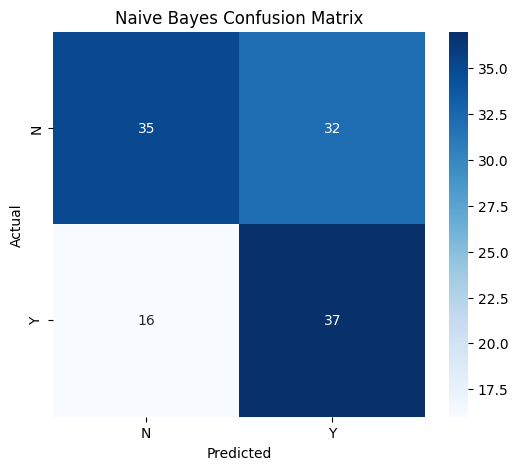

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()